In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
import yfinance as yf

tickers = {
    "target":     ["^GSPC"],
    "volatility": ["^VIX", "^TNX", "^FVX"],
    "indices":    ["^IXIC", "^DJI", "^RUT"],
    "sectors":    ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLB", "XLU", "XLRE"],
    "commodities":["GC=F", "CL=F", "SI=F"],
    "fx":         ["DX-Y.NYB"],
}

all_tickers = [t for group in tickers.values() for t in group]

raw = yf.download(all_tickers, start="2015-01-01", auto_adjust=True)["Close"]

raw = raw.dropna(thresh=int(len(raw) * 0.95), axis=1)

rename_map = {
    "^GSPC":    "spx",
    "^VIX":     "vix",
    "^TNX":     "yield_10y",
    "^FVX":     "yield_5y",
    "^IXIC":    "nasdaq",
    "^DJI":     "dow",
    "^RUT":     "russell",
    "GC=F":     "gold",
    "CL=F":     "oil",
    "SI=F":     "silver",
    "DX-Y.NYB": "usd_index",
}
raw = raw.rename(columns={k: v for k, v in rename_map.items() if k in raw.columns})

returns = np.log(raw / raw.shift(1)).dropna()

returns["target"] = returns["spx"].shift(-1)
returns = returns.dropna()

[*********************100%***********************]  21 of 21 completed
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [ ]:
returns

Ticker,oil,usd_index,gold,silver,XLB,XLE,XLF,XLI,XLK,XLP,...,XLV,XLY,dow,yield_5y,spx,nasdaq,russell,yield_10y,vix,target
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.051603,0.003288,0.014980,0.027890,-0.025818,-0.042248,-0.021251,-0.023636,-0.015383,-0.007057,...,-0.005113,-0.019312,-0.018755,-0.031390,-0.018447,-0.015831,-0.014663,-0.040371,0.113088,-0.008933
2015-01-06,-0.043081,0.001312,0.012711,0.025869,-0.008898,-0.014799,-0.015401,-0.012397,-0.012131,-0.001251,...,-0.003374,-0.010013,-0.007456,-0.049013,-0.008933,-0.012943,-0.017109,-0.037986,0.058496,0.011563
2015-01-07,0.014910,0.004253,-0.007161,-0.005617,0.011216,0.002127,0.010432,0.007494,0.008433,0.016957,...,0.023240,0.015690,0.012180,-0.013486,0.011563,0.012491,0.012545,-0.004595,-0.089597,0.017730
2015-01-08,0.002874,0.005210,-0.001819,-0.009677,0.023501,0.022201,0.014834,0.019831,0.021743,0.015059,...,0.016941,0.014890,0.018221,0.015494,0.017730,0.018265,0.016998,0.031237,-0.126822,-0.008439
2015-01-09,-0.008852,-0.004666,0.006270,0.002138,-0.005151,-0.007957,-0.013589,-0.010769,-0.003147,-0.008112,...,-0.008933,-0.011640,-0.009567,-0.036071,-0.008439,-0.006805,-0.008775,-0.022574,0.031252,-0.008127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,0.002591,0.001310,-0.004150,-0.006842,0.005383,0.006070,0.004051,0.007245,0.009972,0.001652,...,0.011676,0.004036,0.005830,-0.000235,0.003720,0.001933,0.009026,-0.006124,-0.003586,0.000165
2026-05-27,-0.057089,0.000403,-0.011824,-0.022611,0.003719,-0.014978,-0.008328,0.000000,-0.003842,0.011296,...,0.001884,0.017428,0.003612,-0.001435,0.000165,0.000696,-0.000205,-0.002674,-0.043250,0.005737
2026-05-28,0.002478,-0.001917,0.011580,0.013924,0.003511,-0.000702,-0.002921,-0.002873,0.013036,-0.001775,...,0.013949,0.004187,0.000487,-0.004078,0.005737,0.009059,0.005679,-0.005819,-0.034346,0.002170


In [ ]:
returns.index

DatetimeIndex(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14',
               '2015-01-15', '2015-01-16',
               ...
               '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20',
               '2026-05-21', '2026-05-22', '2026-05-27', '2026-05-28',
               '2026-05-29', '2026-06-01'],
              dtype='datetime64[ns]', name='Date', length=2855, freq=None)

In [ ]:
test = returns.loc['2026-01-01':'2026-05-29']
train = returns.loc['2015-01-01':"2025-12-31"]

In [ ]:
X = returns.drop(columns=["target"])
y = returns["target"]
X

Ticker,oil,usd_index,gold,silver,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,dow,yield_5y,spx,nasdaq,russell,yield_10y,vix
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.051603,0.003288,0.014980,0.027890,-0.025818,-0.042248,-0.021251,-0.023636,-0.015383,-0.007057,-0.012301,-0.005113,-0.019312,-0.018755,-0.031390,-0.018447,-0.015831,-0.014663,-0.040371,0.113088
2015-01-06,-0.043081,0.001312,0.012711,0.025869,-0.008898,-0.014799,-0.015401,-0.012397,-0.012131,-0.001251,0.000640,-0.003374,-0.010013,-0.007456,-0.049013,-0.008933,-0.012943,-0.017109,-0.037986,0.058496
2015-01-07,0.014910,0.004253,-0.007161,-0.005617,0.011216,0.002127,0.010432,0.007494,0.008433,0.016957,0.009763,0.023240,0.015690,0.012180,-0.013486,0.011563,0.012491,0.012545,-0.004595,-0.089597
2015-01-08,0.002874,0.005210,-0.001819,-0.009677,0.023501,0.022201,0.014834,0.019831,0.021743,0.015059,0.006945,0.016941,0.014890,0.018221,0.015494,0.017730,0.018265,0.016998,0.031237,-0.126822
2015-01-09,-0.008852,-0.004666,0.006270,0.002138,-0.005151,-0.007957,-0.013589,-0.010769,-0.003147,-0.008112,-0.006312,-0.008933,-0.011640,-0.009567,-0.036071,-0.008439,-0.006805,-0.008775,-0.022574,0.031252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,0.002591,0.001310,-0.004150,-0.006842,0.005383,0.006070,0.004051,0.007245,0.009972,0.001652,0.007748,0.011676,0.004036,0.005830,-0.000235,0.003720,0.001933,0.009026,-0.006124,-0.003586
2026-05-27,-0.057089,0.000403,-0.011824,-0.022611,0.003719,-0.014978,-0.008328,0.000000,-0.003842,0.011296,-0.004200,0.001884,0.017428,0.003612,-0.001435,0.000165,0.000696,-0.000205,-0.002674,-0.043250
2026-05-28,0.002478,-0.001917,0.011580,0.013924,0.003511,-0.000702,-0.002921,-0.002873,0.013036,-0.001775,-0.011362,0.013949,0.004187,0.000487,-0.004078,0.005737,0.009059,0.005679,-0.005819,-0.034346


In [ ]:
target_corr = X.corrwith(y).abs()
weak = target_corr[target_corr < 0.01].index.tolist()
X_filtered = X.drop(columns=weak)

In [ ]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# --- PCA: retain 95% of variance ---
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced to {X_pca.shape[1]} components from {X_filtered.shape[1]} features")
print(f"Variance explained per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

# --- Loadings: which features drive each PC? ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_filtered.columns,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
print(f"\nTop 5 features driving PC1:\n{loadings['PC1'].abs().sort_values(ascending=False).head()}")

PCA reduced to 11 components from 20 features
Variance explained per component:
  PC1: 0.517  (cumulative: 0.517)
  PC2: 0.124  (cumulative: 0.641)
  PC3: 0.079  (cumulative: 0.720)
  PC4: 0.054  (cumulative: 0.775)
  PC5: 0.052  (cumulative: 0.827)
  PC6: 0.038  (cumulative: 0.865)
  PC7: 0.027  (cumulative: 0.892)
  PC8: 0.021  (cumulative: 0.913)
  PC9: 0.018  (cumulative: 0.930)
  PC10: 0.013  (cumulative: 0.944)
  PC11: 0.011  (cumulative: 0.954)

Top 5 features driving PC1:
Ticker
spx        0.304779
dow        0.301553
XLI        0.288670
russell    0.281002
nasdaq     0.277574
Name: PC1, dtype: float64


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
from sklearn.model_selection import  KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])

X = X_filtered.values
y_vals = y.values

tscv = TimeSeriesSplit(n_splits=5)
ts_scores = cross_val_score(pipe, X, y_vals, cv=tscv, scoring="neg_mean_squared_error")


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(pipe, X, y_vals, cv=kfold, scoring="neg_mean_squared_error")

print(f"TimeSeriesSplit MSE: {-ts_scores.mean():.6f} ± {ts_scores.std():.6f}")
print(f"KFold MSE:          {-kf_scores.mean():.6f} ± {kf_scores.std():.6f}")

TimeSeriesSplit MSE: 0.000135 ± 0.000069
KFold MSE:          0.000126 ± 0.000014


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

lasso_selector = LassoCV(cv=tscv, max_iter=10000, random_state=42)
lasso_selector.fit(X_scaled, y)

selected_mask = lasso_selector.coef_ != 0
selected_features = X_filtered.columns[selected_mask].tolist()

X_selected = X_scaled[:, selected_mask]
print(f"LASSO selected {len(selected_features)} features (alpha={lasso_selector.alpha_:.5f}):")
coef_series = pd.Series(lasso_selector.coef_[selected_mask], index=selected_features)
print(coef_series.sort_values(key=abs, ascending=False))

LASSO selected 13 features (alpha=0.00012):
spx         -0.000938
vix         -0.000868
yield_10y   -0.000811
XLP         -0.000479
XLI          0.000438
XLU         -0.000433
XLK         -0.000427
XLV         -0.000246
silver       0.000220
XLF         -0.000215
XLY          0.000204
usd_index   -0.000085
XLE         -0.000063
dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

models = {
    "OLS":   LinearRegression(),
    "Ridge": RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=tscv),
    "LASSO": LassoCV(cv=tscv, max_iter=10000, random_state=42),
}

inputs = {
    "OLS":   X_selected,
    "Ridge": X_selected,
    "LASSO": X_scaled,
}

results = {}

for name, model in models.items():
    X_in = inputs[name]
    mse_scores, mae_scores, dir_scores = [], [], []

    for train_idx, val_idx in tscv.split(X_in):
        X_train, X_val = X_in[train_idx], X_in[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mse_scores.append(mean_squared_error(y_val, y_pred))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        dir_scores.append(np.mean(np.sign(y_pred) == np.sign(y_val)))

    results[name] = {
        "MSE":      np.mean(mse_scores),
        "MAE":      np.mean(mae_scores),
        "Dir Acc":  np.mean(dir_scores),
        "MSE std":  np.std(mse_scores),
    }

naive_mse, naive_dir = [], []
for _, val_idx in tscv.split(X_scaled):
    y_val = y.iloc[val_idx]
    naive_mse.append(mean_squared_error(y_val, np.zeros(len(y_val))))
    naive_dir.append(np.mean(np.sign(np.zeros(len(y_val))) == np.sign(y_val)))

results["Naive (0)"] = {
    "MSE":     np.mean(naive_mse),
    "MAE":     np.mean(naive_mse),
    "Dir Acc": np.mean(naive_dir),
    "MSE std": np.std(naive_mse),
}

results_df = pd.DataFrame(results).T
results_df = results_df.round(6)
print("\n=============== Model Comparison ===============")
print(results_df.to_string())



=============== Model Comparison ===============
                MSE       MAE   Dir Acc   MSE std
OLS        0.000134  0.007632  0.525895  0.000071
Ridge      0.000133  0.007497  0.528421  0.000074
LASSO      0.000136  0.007482  0.538105  0.000081
Naive (0)  0.000134  0.000134  0.000421  0.000081


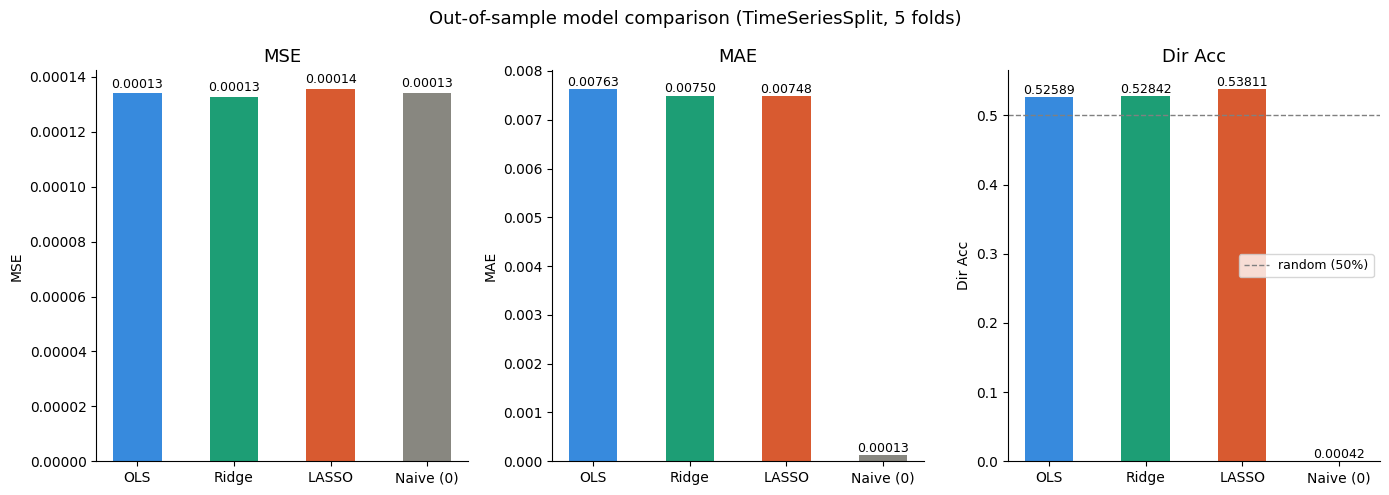

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = list(results.keys())
colors = ["#378ADD", "#1D9E75", "#D85A30", "#888780"]

for ax, metric in zip(axes, ["MSE", "MAE", "Dir Acc"]):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000001,
                f"{val:.5f}", ha="center", va="bottom", fontsize=9)
    if metric == "Dir Acc":
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random (50%)")
        ax.legend(fontsize=9)

plt.suptitle("Out-of-sample model comparison (TimeSeriesSplit, 5 folds)", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



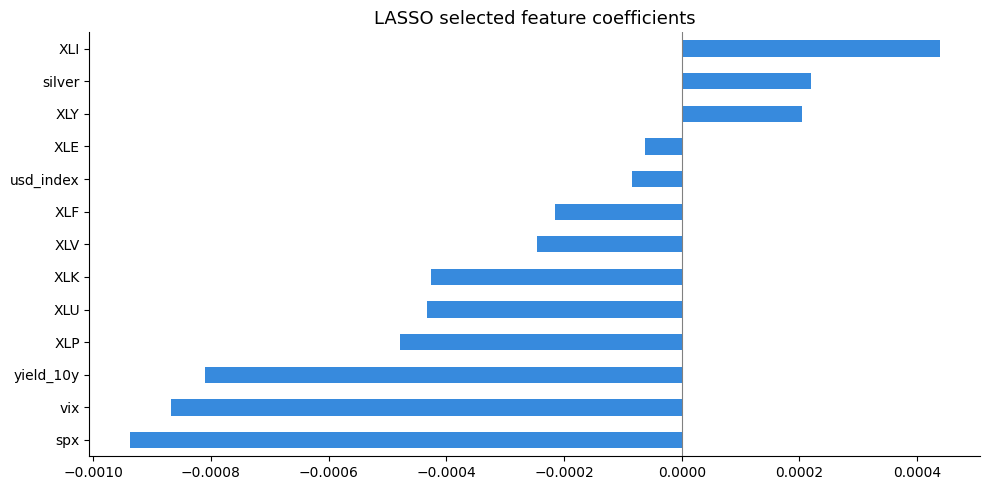

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
coef_series.sort_values().plot(kind="barh", ax=ax, color="#378ADD")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("LASSO selected feature coefficients", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("lasso_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**Final Model Comparison: Sector-Only vs Full Predictors vs PCA vs LASSO**

We compare four predictor strategies:

1. **Sector-only predictors**: uses only sector ETF returns as a baseline.
2. **Full predictors**: uses all candidate market, macro, commodity, and sector indicators after correlation filtering.
3. **PCA predictors**: transforms the full predictor set into principal components explaining 95% of variance.
4. **LASSO-selected predictors**: uses LASSO regularization to select a sparse set of predictors.

All models are evaluated with TimeSeriesSplit so that each validation fold occurs after its corresponding training fold. This avoids using future data to predict the past.

In [ ]:
# Use the same filtered predictors created earlier.
X_full = X_filtered.copy()
y_full = y.copy()

sector_cols = [
    "XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLB", "XLU", "XLRE", "XLC"
]
sector_cols = [c for c in sector_cols if c in X_full.columns]
X_sector = X_full[sector_cols].copy()

print(f"Full predictor set: {X_full.shape[1]} predictors")
print(f"Sector-only predictor set: {X_sector.shape[1]} predictors")
print("Sector predictors used:", sector_cols)

Full predictor set: 20 predictors
Sector-only predictor set: 9 predictors
Sector predictors used: ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLB', 'XLU']


In [ ]:
def evaluate_cv(model, X_data, y_data, cv):
    """Evaluate a model or pipeline with time-series cross-validation."""
    rows = []
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_data), start=1):
        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]
        y_train = y_data.iloc[train_idx]
        y_val = y_data.iloc[val_idx]

        fitted = clone(model)
        fitted.fit(X_train, y_train)
        y_pred = fitted.predict(X_val)

        rows.append({
            "Fold": fold,
            "MSE": mean_squared_error(y_val, y_pred),
            "MAE": mean_absolute_error(y_val, y_pred),
            "Directional Accuracy": np.mean(np.sign(y_pred) == np.sign(y_val))
        })
    return pd.DataFrame(rows)

outer_cv = TimeSeriesSplit(n_splits=5)
inner_cv = TimeSeriesSplit(n_splits=3)

alphas = np.logspace(-4, 2, 30)

comparison_models = {
    "Naive zero-return baseline": {
        "Feature Set": "None",
        "Model": None,
        "X": X_full
    },
    "Sector-only OLS": {
        "Feature Set": "Sector-only raw predictors",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "X": X_sector
    },
    "Sector-only Ridge": {
        "Feature Set": "Sector-only raw predictors",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=alphas, cv=inner_cv))
        ]),
        "X": X_sector
    },
    "Full OLS": {
        "Feature Set": "Full raw predictors",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "X": X_full
    },
    "Full Ridge": {
        "Feature Set": "Full raw predictors",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=alphas, cv=inner_cv))
        ]),
        "X": X_full
    },
    "Full PCA + Ridge": {
        "Feature Set": "Full predictors converted to PCs",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", RidgeCV(alphas=alphas, cv=inner_cv))
        ]),
        "X": X_full
    },
    "Sector PCA + Ridge": {
        "Feature Set": "Sector predictors converted to PCs",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", RidgeCV(alphas=alphas, cv=inner_cv))
        ]),
        "X": X_sector
    },
    "Full LASSO": {
        "Feature Set": "Full predictors with LASSO selection",
        "Model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(alphas=alphas, cv=inner_cv, max_iter=10000, random_state=42))
        ]),
        "X": X_full
    }
}

all_results = []

for name, spec in comparison_models.items():
    X_data = spec["X"]
    model = spec["Model"]

    if model is None:
        fold_rows = []
        for fold, (_, val_idx) in enumerate(outer_cv.split(X_data), start=1):
            y_val = y_full.iloc[val_idx]
            y_pred = np.zeros(len(y_val))
            fold_rows.append({
                "Fold": fold,
                "MSE": mean_squared_error(y_val, y_pred),
                "MAE": mean_absolute_error(y_val, y_pred),
                "Directional Accuracy": np.mean(np.sign(y_pred) == np.sign(y_val))
            })
        fold_df = pd.DataFrame(fold_rows)
    else:
        fold_df = evaluate_cv(model, X_data, y_full, outer_cv)

    summary = {
        "Comparison": name,
        "Feature Set": spec["Feature Set"],
        "Predictors Entering Pipeline": X_data.shape[1],
        "CV MSE": fold_df["MSE"].mean(),
        "CV MSE SD": fold_df["MSE"].std(),
        "CV MAE": fold_df["MAE"].mean(),
        "CV Directional Accuracy": fold_df["Directional Accuracy"].mean()
    }
    all_results.append(summary)

comparison_df = pd.DataFrame(all_results).sort_values("CV MSE")
comparison_df.round(6)

,Comparison,Feature Set,Predictors Entering Pipeline,CV MSE,CV MSE SD,CV MAE,CV Directional Accuracy
5,Full PCA + Ridge,Full predictors converted to PCs,20,0.000133,0.000083,0.007504,0.511579
4,Full Ridge,Full raw predictors,20,0.000133,0.000082,0.007509,0.515368
6,Sector PCA + Ridge,Sector predictors converted to PCs,9,0.000134,0.000087,0.007490,0.499368
0,Naive zero-return baseline,None,20,0.000134,0.000091,0.007428,0.000421
2,Sector-only Ridge,Sector-only raw predictors,9,0.000135,0.000087,0.007512,0.502737
3,Full OLS,Full raw predictors,20,0.000135,0.000078,0.007671,0.515789
7,Full LASSO,Full predictors with LASSO selection,20,0.000135,0.000090,0.007477,0.538947
1,Sector-only OLS,Sector-only raw predictors,9,0.000136,0.000086,0.007601,0.499789


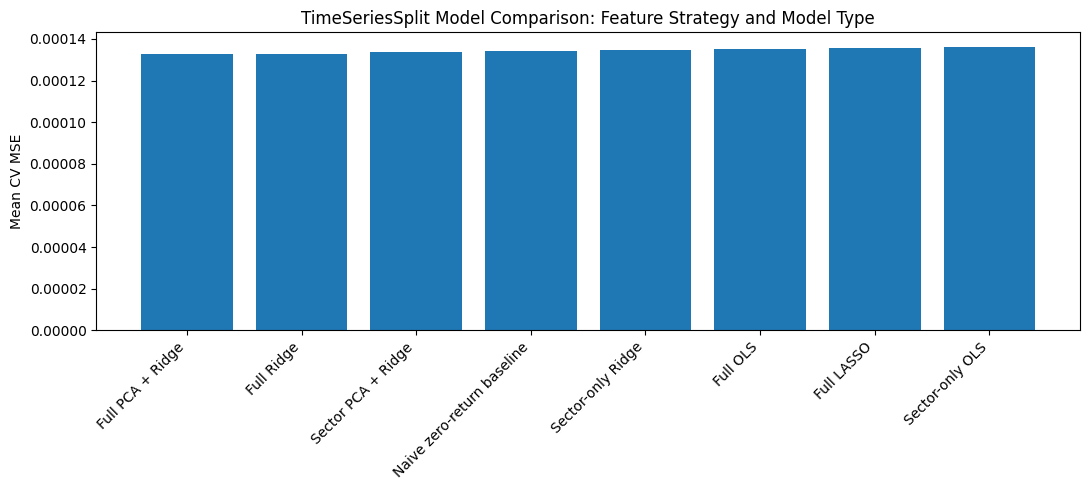

In [ ]:
# Plot the cross-validated MSE for each feature/model strategy.
comparison_df.sort_values("CV MSE")
plt.figure(figsize=(11, 5))
plt.bar(comparison_df["Comparison"], comparison_df["CV MSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean CV MSE")
plt.title("TimeSeriesSplit Model Comparison: Feature Strategy and Model Type")
plt.tight_layout()
plt.savefig("final_model_comparison_mse.png", dpi=150, bbox_inches="tight")
plt.show()

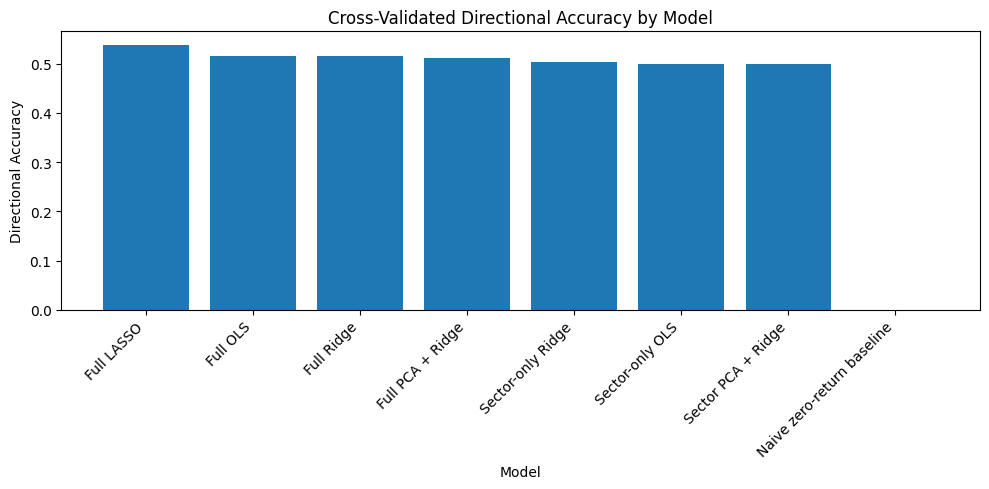

In [ ]:
plot_df = comparison_df.sort_values(
    "CV Directional Accuracy",
    ascending=False
)

plt.figure(figsize=(10,5))
plt.bar(
    plot_df["Comparison"],
    plot_df["CV Directional Accuracy"]
)

plt.ylabel("Directional Accuracy")
plt.xlabel("Model")
plt.title("Cross-Validated Directional Accuracy by Model")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
baseline_mse = comparison_df.loc[
    comparison_df["Comparison"] == "Naive zero-return baseline",
    "CV MSE"
].iloc[0]

comparison_df["MSE Improvement"] = (
    baseline_mse - comparison_df["CV MSE"]
)

In [ ]:
# inspect lasso selected features
lasso_final = LassoCV(alphas=alphas, cv=inner_cv, max_iter=10000, random_state=42)
lasso_final.fit(X_scaled, y)

selected = pd.DataFrame(X).columns[lasso_final.coef_ != 0]
print(selected)

Index([1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 15, 18, 19], dtype='int64')


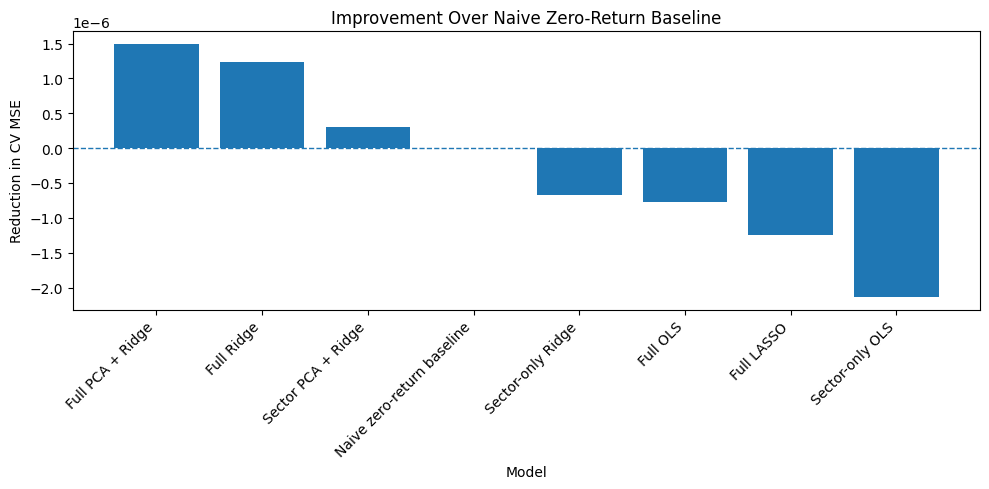

In [ ]:
plot_df = comparison_df.sort_values(
    "MSE Improvement",
    ascending=False
)

plt.figure(figsize=(10,5))
plt.bar(
    plot_df["Comparison"],
    plot_df["MSE Improvement"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.ylabel("Reduction in CV MSE")
plt.xlabel("Model")
plt.title("Improvement Over Naive Zero-Return Baseline")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
comparison_df[["Comparison","CV MSE"]].sort_values("CV MSE")

,Comparison,CV MSE
5,Full PCA + Ridge,0.000133
4,Full Ridge,0.000133
6,Sector PCA + Ridge,0.000134
0,Naive zero-return baseline,0.000134
2,Sector-only Ridge,0.000135
3,Full OLS,0.000135
7,Full LASSO,0.000135
1,Sector-only OLS,0.000136


**FOR MSE**

Winner: Full PCA + Ridge

Compressing correlated financial indicators into latent factors reduced noise and improved prediction accuracy.

**FOR DIRECTIONAL ACCURACY**

Winner: Full LASSO

Compressing correlated financial indicators into latent factors reduced noise and improved prediction accuracy.


**Trade-Off**

| Objective                    | Best Model       |
| ---------------------------- | ---------------- |
| Lowest CV MSE                | Full PCA + Ridge |
| Highest Directional Accuracy | Full LASSO       |
| Most Interpretable           | Full LASSO       |
| Most Compact Representation  | PCA              |


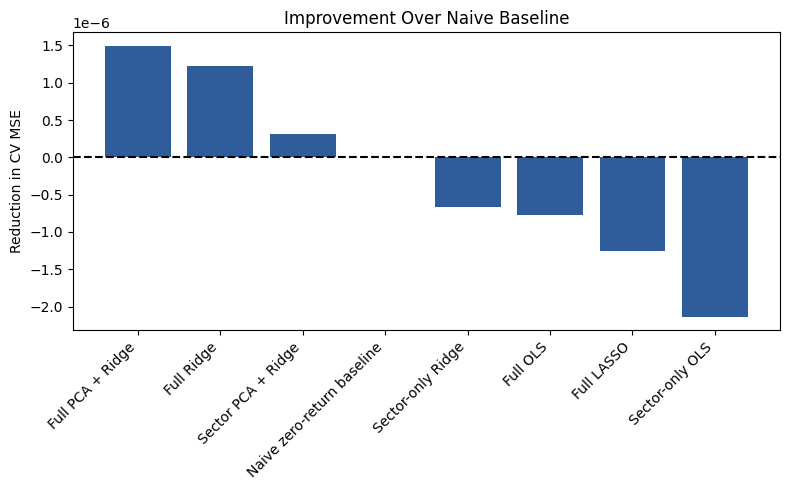

In [ ]:
figsize=(10, 6)
dpi=300

baseline_mse = comparison_df.loc[
    comparison_df["Comparison"] ==
    "Naive zero-return baseline",
    "CV MSE"
].iloc[0]

comparison_df["MSE Improvement"] = (
    baseline_mse - comparison_df["CV MSE"]
)

plot_df = comparison_df.sort_values(
    "MSE Improvement",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    plot_df["Comparison"],
    plot_df["MSE Improvement"],
    color="#2F5D9B"
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.ylabel("Reduction in CV MSE")
plt.title("Improvement Over Naive Baseline")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

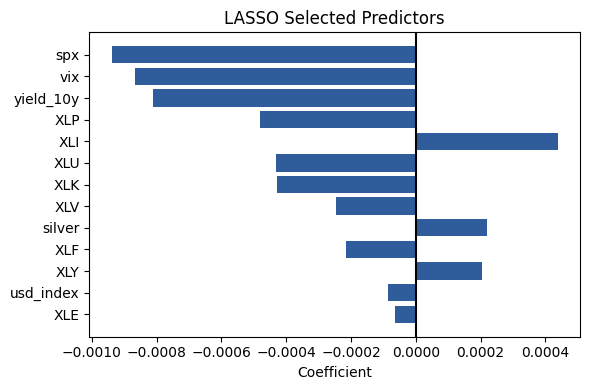

In [ ]:
lasso_summary["AbsCoef"] = (
    lasso_summary["Coefficient"].abs()
)

lasso_summary = lasso_summary.sort_values(
    "AbsCoef",
    ascending=True
)

plt.figure(figsize=(6,4))

plt.barh(
    lasso_summary["Predictor"],
    lasso_summary["Coefficient"],
    color="#2F5D9B"
)

plt.axvline(
    0,
    color="black"
)

plt.title("LASSO Selected Predictors")
plt.xlabel("Coefficient")

plt.tight_layout()
plt.show()